In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("world_data_full_apply_nulos.csv", index_col=0)
df.head()

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe
2,Algeria,18.0,DZ,17.4,NaN,317.0,24.28,213.0,Algiers,150.006,151.36,2.0,DZD,3.02,0.8,0.28,1.699882e+11,109.9,51.4,20.1,Algiers,76.7,112.0,0.95,Arabic,28.1,1.72,NaN,41.2,37.2,66.1,11.70,NaN,28.033886,1.659626,Africa
3,Andorra,164.0,AD,40.0,468.000,NaN,7.20,376.0,Andorra la Vella,469.000,NaN,NaN,EUR,1.27,34.0,1.51,3.154058e+09,106.4,NaN,2.7,Andorra la Vella,NaN,NaN,6.63,Catalan,36.4,3.33,77.142,NaN,NaN,NaN,NaN,67.873,42.506285,1.521801,Europe
4,Angola,26.0,AO,47.5,NaN,117.0,40.73,244.0,Luanda,34.693,261.73,17.1,AOA,5.52,46.3,0.97,9.463542e+10,113.5,9.3,51.6,Luanda,60.8,241.0,0.71,Portuguese,33.4,0.21,NaN,77.5,9.2,49.1,6.89,NaN,-11.202692,17.873887,Africa


# Pair Estadística Descriptiva II

### Conjunto de datos:

### **Ejercicios estadística descriptiva**

Imagina que eres un analista de datos que trabaja para una organización internacional enfocada en el desarrollo y el bienestar de los países. Tu objetivo es realizar un **primer análisis descriptivo**, centrándote en:

* Cómo se distribuyen algunas **variables categóricas** entre los países (continente, idioma, etc.).
* Qué relaciones básicas podemos ver entre esas categorías.
* Y, al final, explorar **una correlación numérica concreta** relacionada con el desarrollo (fertilidad y esperanza de vida).

#### 1. Relación entre fertilidad y esperanza de vida

Variables:

* `fertility_rate`
* `life_expectancy`

1. Calcula el **coeficiente de correlación de Pearson** entre `fertility_rate` y `life_expectancy`.


In [11]:
natalidad_vs_esperanza = df[['fertility_rate','life_expectancy']]


In [16]:
natalidad_vs_esperanza.corr(method='pearson')

,fertility_rate,life_expectancy
fertility_rate,1.000000,-0.849153
life_expectancy,-0.849153,1.000000


2. Crea un **diagrama de dispersión** (scatter plot) con:
   * Eje X: `fertility_rate`
   * Eje Y: `life_expectancy`


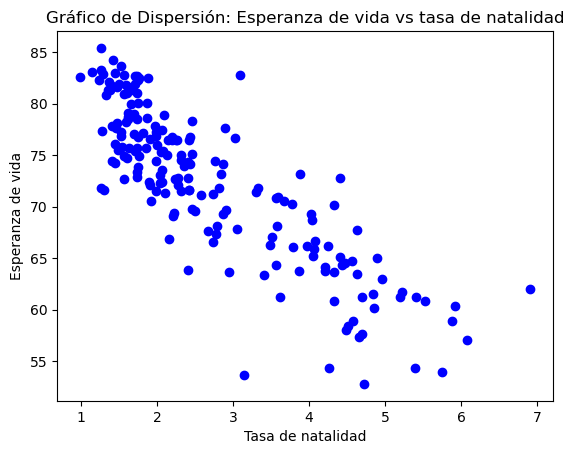

In [17]:
plt.scatter(x=df['fertility_rate'], y=df['life_expectancy'], color="blue")
plt.title('Gráfico de Dispersión: Esperanza de vida vs tasa de natalidad')
plt.xlabel('Tasa de natalidad')
plt.ylabel('Esperanza de vida')
plt.show()

3. Interpreta:
   * ¿La correlación es positiva o negativa? ¿Es fuerte, moderada o débil?
   * Describe, en lenguaje de negocio, qué significa esta relación:
     * “En general, los países con X tienden a tener Y…”.


Las dos variables tiene un coeficiente de correlación de -0.84 por lo que se considera una relación negativa fuerte.
Por lo tanto, los paises con mayor esperanza de vida tienen una tasa de natalidad más baja.



#### 2. PIB, emisiones y población: ¿qué se relaciona con qué?

Variables:

* `gdp`
* `co2-emissions`
* `population`

1. Calcula una **matriz de correlación** solo con estas tres variables.


In [22]:
PIB_em_pob = df[['gdp','co2-emissions', 'population']].dropna()

In [23]:
correlation_matrix = PIB_em_pob.corr(method='pearson')

2. (Opcional) Representa la matriz en un **heatmap**.


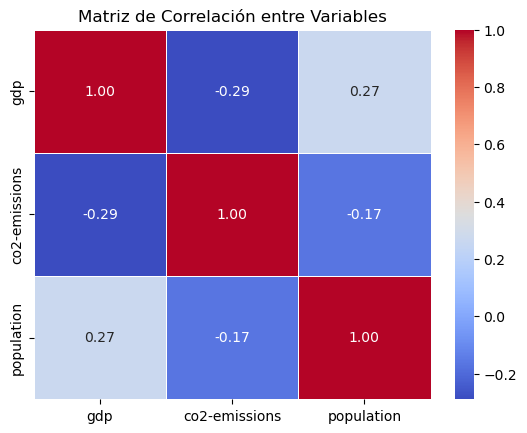

In [24]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

# Añade título
plt.title('Matriz de Correlación entre Variables')

# Muestra el gráfico

plt.show()

3. Interpreta:
   * ¿Qué par de variables tiene la correlación más alta?
   * ¿Tiene sentido desde el punto de vista económico/medioambiental?
   * ¿Hay algún par con correlación muy baja (cerca de 0)? ¿Qué interpretación darías?


Las dos variables con la correlación más alta son el PIB y co2, con un coeficiente de correlación de 0,48 que se considera moderada.
No se puede afirmar ya que tiene una correlación moderada.
Población con emisiones de co2 con una correlación de -0,17, que podríamos interpretar que no guardan ningún tipo de relación.



#### 3. Distribución de países por continente (variable categórica)

Variable categórica: `continent`

1. Calcula la **tabla de frecuencias** de `continent`:
   * Frecuencia absoluta (número de países por continente).
   * Frecuencia relativa o porcentaje sobre el total.


In [29]:
frecuencia_ab =df['continent'].value_counts()
frecuencia_ab

continent
Africa             53
Europe             47
Asia               45
Central America    20
Oceania            14
South America      13
North America       2
Name: count, dtype: int64

In [30]:
frecuencia_relativa = df['continent'].value_counts(normalize=True) * 100
frecuencia_relativa

continent
Africa             27.319588
Europe             24.226804
Asia               23.195876
Central America    10.309278
Oceania             7.216495
South America       6.701031
North America       1.030928
Name: proportion, dtype: float64

2. Interpreta:
   * ¿Qué continente tiene más países en el dataset?
   * ¿Qué continentes están menos representados?
   * Desde el punto de vista de un analista, ¿por qué es importante conocer esta distribución antes de comparar indicadores entre continentes?


África es el continente con más paises
Norte América es el pais menos representado
Para saber el tamaño muestral de paises por continente antes de hacer cualquier análisis



#### 4. Idioma oficial: ¿qué idiomas son más frecuentes?

Variable categórica: `official_language`

1. Calcula la **frecuencia absoluta y relativa** de `official_language`.


In [31]:
frecuencia_ab =df['official_language'].value_counts()
frecuencia_ab

official_language
English              31
French               25
Spanish              19
Arabic               18
Portuguese            7
                     ..
Tuvaluan Language     1
Ukrainian             1
Uzbek                 1
Vietnamese            1
Shona                 1
Name: count, Length: 76, dtype: int64

In [32]:
frecuencia_relativa = df['official_language'].value_counts(normalize=True) * 100
frecuencia_relativa

official_language
English              16.315789
French               13.157895
Spanish              10.000000
Arabic                9.473684
Portuguese            3.684211
                       ...    
Tuvaluan Language     0.526316
Ukrainian             0.526316
Uzbek                 0.526316
Vietnamese            0.526316
Shona                 0.526316
Name: proportion, Length: 76, dtype: float64

2. Identifica:
   * Los 5 idiomas oficiales más frecuentes.


Los idiomas más frecuentes son Inglés, Francés, Español, Ärabe y Portugués.

3. Interpreta:
   * ¿Hay algún idioma claramente dominante?
   * ¿Qué implicaciones podría tener esto a la hora de diseñar encuestas, campañas o informes internacionales?

*(Si hay demasiadas categorías, puedes usar algo como `value_counts().head(10)` para ver solo las más frecuentes.)*


El inglés, pero no sería claramente dominante. 



#### 5. Continente vs. nivel de ingresos

En esta base de datos tenemos `gdp` (Producto Interno Bruto per cápita aproximado). Crea primero una **variable categórica derivada** a partir de `gdp`, por ejemplo:

* `bajo`: países con `gdp` por debajo del percentil 33.
* `medio`: entre los percentiles 33 y 66.
* `alto`: por encima del percentil 66.

Puedes llamarla, por ejemplo, `gdp_level`.

1. Crea la nueva columna `gdp_level` en el DataFrame.


In [33]:
Q33 = df['gdp'].quantile(0.33)
Q66 = df['gdp'].quantile(0.66)

In [35]:
condiciones = [
    df['gdp'] <= Q33,
    (df['gdp'] > Q33) & (df['gdp'] < Q66),
    df['gdp'] >= Q66
]

valores = ['bajo', 'medio', 'alto']

df['gdp_level'] = np.select(condiciones, valores, default=None)

In [36]:
df.head()

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent,gdp_level
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia,medio
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe,medio
2,Algeria,18.0,DZ,17.4,NaN,317.0,24.28,213.0,Algiers,150.006,151.36,2.0,DZD,3.02,0.8,0.28,1.699882e+11,109.9,51.4,20.1,Algiers,76.7,112.0,0.95,Arabic,28.1,1.72,NaN,41.2,37.2,66.1,11.70,NaN,28.033886,1.659626,Africa,alto
3,Andorra,164.0,AD,40.0,468.000,NaN,7.20,376.0,Andorra la Vella,469.000,NaN,NaN,EUR,1.27,34.0,1.51,3.154058e+09,106.4,NaN,2.7,Andorra la Vella,NaN,NaN,6.63,Catalan,36.4,3.33,77.142,NaN,NaN,NaN,NaN,67.873,42.506285,1.521801,Europe,bajo
4,Angola,26.0,AO,47.5,NaN,117.0,40.73,244.0,Luanda,34.693,261.73,17.1,AOA,5.52,46.3,0.97,9.463542e+10,113.5,9.3,51.6,Luanda,60.8,241.0,0.71,Portuguese,33.4,0.21,NaN,77.5,9.2,49.1,6.89,NaN,-11.202692,17.873887,Africa,alto


2. Construye una **tabla de contingencia** entre:
   * Filas: `continent`
   * Columnas: `gdp_level`


In [43]:
tabla_contingencia = pd.crosstab(df['continent'], df['gdp_level'], normalize= 'index') * 100
tabla_contingencia

gdp_level,alto,bajo,medio
continent,,,
Africa,15.094340,47.169811,37.735849
Asia,45.454545,15.909091,38.636364
Central America,15.000000,55.000000,30.000000
Europe,52.173913,15.217391,32.608696
North America,100.000000,0.000000,0.000000
Oceania,14.285714,78.571429,7.142857
South America,53.846154,15.384615,30.769231


3. Normaliza la tabla por filas (porcentaje dentro de cada continente).


4. Interpreta:
   * ¿Qué continentes concentran más países en el grupo de `gdp` **alto**?
   * ¿Hay algún continente donde predominen claramente los países de `gdp` **bajo**?
   * ¿Qué conclusiones preliminares (no definitivas) podrías extraer sobre la distribución de riqueza por continente?


Europa es el continente que mas países concentra en el gdp alto.

Asia y Sudamérica. 

Está muy disperso hay continentes con un PIB muy alto y otros muy bajos. 




#### 6. Idioma oficial vs. continente

Queremos ver la relación entre **continente** e **idioma oficial**.

Variables categóricas:

* `continent`
* `official_language`

1. Crea una **tabla de contingencia**:
   * Filas: `continent`
   * Columnas: `official_language`

2. Normaliza por filas (`normalize="index"`) para obtener porcentajes.


In [49]:
continente_vs_idioma = pd.crosstab(df['continent'], df['official_language'], normalize= 'index') * 100
print(continente_vs_idioma)

official_language  Afrikaans  Albanian   Amharic     Arabic  Armenian  \
continent                                                               
Africa              1.886792   0.00000  1.886792  13.207547  0.000000   
Asia                0.000000   0.00000  0.000000  25.000000  2.272727   
Central America     0.000000   0.00000  0.000000   0.000000  0.000000   
Europe              0.000000   2.12766  0.000000   0.000000  0.000000   
North America       0.000000   0.00000  0.000000   0.000000  0.000000   
Oceania             0.000000   0.00000  0.000000   0.000000  0.000000   
South America       0.000000   0.00000  0.000000   0.000000  0.000000   

official_language  Azerbaijani language   Bengali  Bosnian  Bulgarian  \
continent                                                               
Africa                         0.000000  0.000000  0.00000    0.00000   
Asia                           2.272727  2.272727  0.00000    0.00000   
Central America                0.000000  0.000000 

3. Interpreta:
   * ¿Hay continentes donde uno o dos idiomas dominen claramente?
   * ¿En qué continente ves más diversidad de idiomas?
   * Desde el punto de vista de políticas internacionales, ¿por qué puede ser útil esta información?

*(Si la tabla es muy grande, puedes filtrar a los 5–10 idiomas más frecuentes antes de construirla.)*



En África hay dos idiomas predominantes que son inglés y francés.
Europa es el continente con más diversidad de idiomas




#### 7. Fertilidad y esperanza de vida: correlación entre variables numéricas

Ahora pasamos a una relación entre dos **variables numéricas**:

* `fertility_rate`
* `life_expectancy`

1. Calcula el **coeficiente de correlación de Pearson** entre `fertility_rate` y `life_expectancy`.


In [ ]:
corr_pearson = df["fertility_rate", "life_expectancy"]

2. Representa, si puedes, un **diagrama de dispersión (scatter plot)** de `fertility_rate` (eje X) vs. `life_expectancy` (eje Y).


3. Interpreta:
   * ¿La correlación es positiva o negativa? ¿Es fuerte, moderada o débil?
   * ¿Tiene sentido esta relación desde el punto de vista demográfico?
   * ¿Podrías explicar, en lenguaje de negocio/políticas públicas, qué significa “a mayor tasa de fertilidad, tiende a ocurrir X con la esperanza de vida”?




#### 8. Bonus: clasificación y resumen de mortalidad infantil (categorías a partir de numérica)

Variable numérica: `infant_mortality`

1. Crea una **variable categórica** a partir de `infant_mortality`, por ejemplo:

   * `baja` mortalidad infantil
   * `moderada`
   * `alta`

   (Puedes definir los cortes usando percentiles, o umbrales que tú elijas y documentes.)


2. Calcula la **tabla de frecuencias** de esta nueva variable categórica.


3. Crea una **tabla de contingencia** entre:
   * Filas: `continent`
   * Columnas: categoría de mortalidad infantil.


4. Interpreta:
   * ¿Qué continentes concentran más países con **alta** mortalidad infantil?
   * ¿Hay continentes donde predominan los países con **baja** mortalidad?
   * ¿Qué tipo de prioridades podría marcarse una organización internacional a partir de este análisis?

***

Recuerda siempre acompañar los cálculos con una **pequeña interpretación** como analista de datos: no solo “qué números salen”, sino **qué implican** sobre la situación de los países.
